In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.375.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.704.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.8597.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.5740.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.5703.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.7717.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.2618.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.1956.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.5608.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.5646.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.7267.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.5341.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.7792.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.2888.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.3808.jpg
/kaggle/input/dogs-vs-cats/dogs_vs_cats/test/dogs/dog.838

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D , MaxPooling2D , Flatten , BatchNormalization , Dropout

In [13]:
raw_train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogs-vs-cats/train',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(256,256)
)

raw_val_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogs-vs-cats/test',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(256,256)
)

print("Train classes:", raw_train_ds.class_names)
print("Val classes:", raw_val_ds.class_names)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Train classes: ['cats', 'dogs']
Val classes: ['cats', 'dogs']


In [14]:
#Normalize

def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.clip_by_value(image, 0.0, 1.0)   # prevent NaNs
    return image, label

train_ds = raw_train_ds.map(process)
validation_ds = raw_val_ds.map(process)


In [15]:
strategy = tf.distribute.MirroredStrategy()

In [7]:
from keras.optimizers import Adam

In [16]:
#create a CNN model
model = Sequential()
    
model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))
    
model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))
    
model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))
    
model.add(Flatten())
    
model.add(Dense(128 , activation='relu'))
model.add(Dense(64 , activation='relu'))
model.add(Dense(1 , activation='sigmoid'))
    
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
for images, labels in train_ds.take(1):
    print("Any NaN in images:", tf.math.reduce_any(tf.math.is_nan(images)).numpy())
    print("Any Inf in images:", tf.math.reduce_any(tf.math.is_inf(images)).numpy())
    print("Image min:", tf.reduce_min(images).numpy(), "max:", tf.reduce_max(images).numpy())

Any NaN in images: False
Any Inf in images: False
Image min: 0.0 max: 1.0


In [19]:
history= model.fit(train_ds, epochs=20 , validation_data=validation_ds)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.5983 - loss: 0.7094 - val_accuracy: 0.7382 - val_loss: 0.5206
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7524 - loss: 0.5034 - val_accuracy: 0.7754 - val_loss: 0.4814
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8171 - loss: 0.4061 - val_accuracy: 0.7860 - val_loss: 0.4555
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.8622 - loss: 0.3186 - val_accuracy: 0.8018 - val_loss: 0.4790
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9147 - loss: 0.2092 - val_accuracy: 0.7882 - val_loss: 0.6117
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.9534 - loss: 0.1217 - val_accuracy: 0.8002 - val_loss: 0.7470
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9740 - loss: 0.0698 - val_accuracy: 0.7926 - val_loss: 0.9607
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9787 - loss: 0.0634 - 

In [ ]:
#ways to reduce overfitting

#add more data
#data augmentation
#l1/l2 regularization
#batch norm
#reduce complexity

In [20]:
with strategy.scope():

    model = Sequential()
    
    model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))
    
    model.add(Conv2D(64, kernel_size=(3,3), padding='valid', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))
    
    model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), strides=2 , padding='valid'))
    
    model.add(Flatten())
    
    model.add(Dense(128 , activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(64 , activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1 , activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Save as TensorFlow SavedModel
saved_model_path = "/kaggle/working/cats_vs_dogs_savedmodel"
model.export(saved_model_path)
print(f"✅ Model exported in TensorFlow SavedModel format at: {saved_model_path}")

# Save as Keras and HDF5
model.save("/kaggle/working/cats_vs_dogs_model.keras")
print("✅ Model saved in Keras format at: /kaggle/working/cats_vs_dogs_model.keras")

model.save("/kaggle/working/cats_vs_dogs_model.h5")
print("✅ Model also saved in HDF5 format at: /kaggle/working/cats_vs_dogs_model.h5")

Saved artifact at '/kaggle/working/cats_vs_dogs_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_112')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132274410125840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132274410126224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132274410126992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132274410126032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132274410125648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132274410125072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132274410118160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273655022800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273655022992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132273655024336: TensorSpec(shape=(), dtype=tf.resource, 

In [23]:
import shutil

# Zip the entire /kaggle/working directory
shutil.make_archive("/kaggle/working/all_files", 'zip', "/kaggle/working")

'/kaggle/working/all_files.zip'

In [24]:
print(model.input_shape)

(None, 256, 256, 3)


In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np


img_path = '/kaggle/input/testing/images (7).jpeg' 

In [29]:
import matplotlib.pyplot as plt

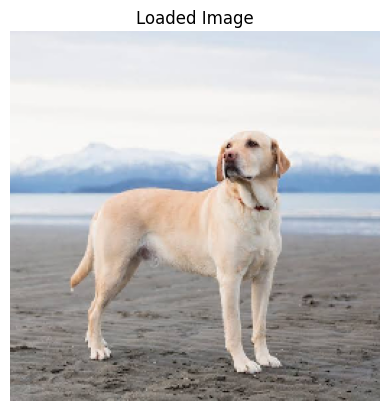

In [30]:
img = image.load_img(img_path, target_size=(256, 256))
plt.imshow(img)
plt.axis('off')
plt.title("Loaded Image")
plt.show()

In [31]:
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # normalize to [0, 1]
img_array = np.expand_dims(img_array, axis=0) 

In [32]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step


In [33]:
if pred[0][0] > 0.5:
    print('Prediction: Dog')
else:
    print('Prediction: Cat')

Prediction: Dog


In [37]:
img_path = '/kaggle/input/testin-cat/images (8).jpeg' 

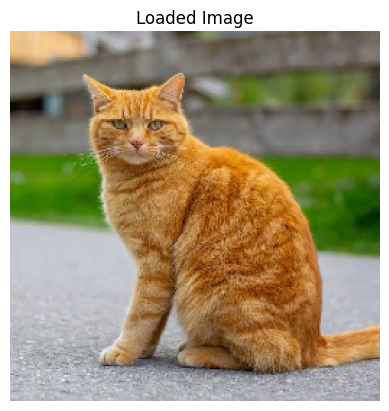

In [38]:
img = image.load_img(img_path, target_size=(256, 256))
plt.imshow(img)
plt.axis('off')
plt.title("Loaded Image")
plt.show()

In [39]:
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # normalize to [0, 1]
img_array = np.expand_dims(img_array, axis=0) 

In [40]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [41]:
if pred[0][0] > 0.5:
    print('Prediction: Dog')
else:
    print('Prediction: Cat')

Prediction: Dog
